In [3]:
#all dependencies 
%pip install scikit-learn pandas numpy matplotlib pvmismatch pvlib numpy
%load_ext autoreload
%autoreload 2

#import the python files needed
import predicting_parameters.cell_ann as cell_ann
from predicting_parameters.refactored_single_cell import Cell
import predicting_parameters.refactored_prediction as refactored_prediction
import power_tracking.refactored_whole_module as refactored_whole_module
import power_tracking.DPSO_MPPT as DPSO_MPPT

Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


# Demo
## Predicting Parameters
The first step is to predict the parameters for a single cell. Parameters include $I_{ph}$, $I_o$, $R_s$, $R_{sh}$, and $a$ This is originally done with a least square method and heuristics. This requires datasheet variables including the Voc, Isc, Pmp and temperature coefficients. 

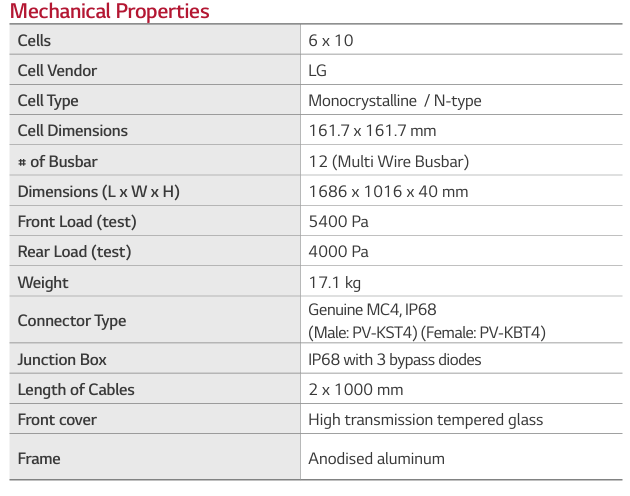

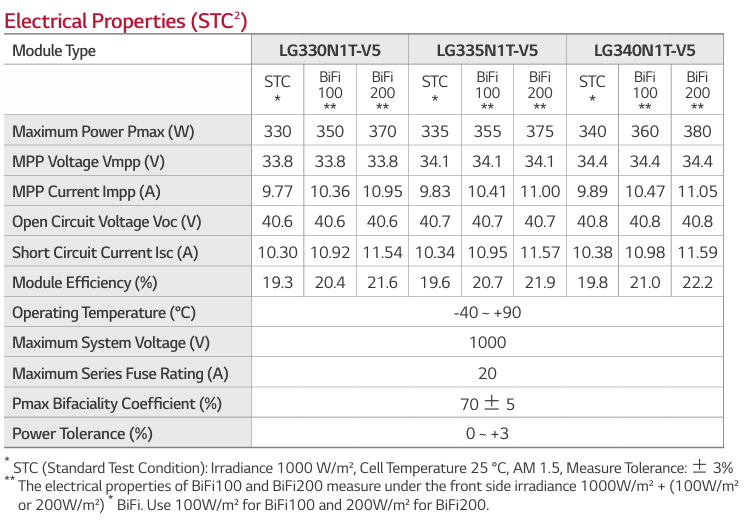

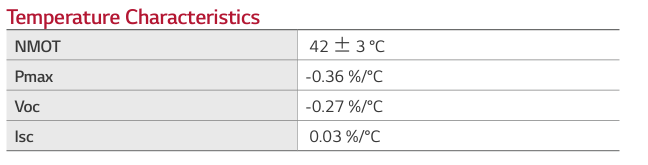

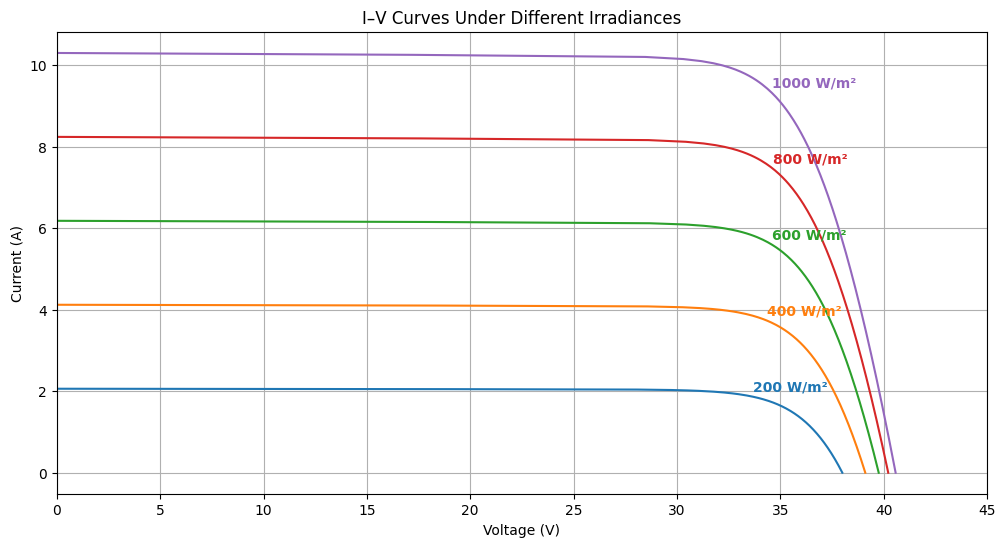

In [5]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

def get_curve(a, iph, isat, rs, rsh, specs):
    max_v = 0
    voltages = []
    current_targets = np.linspace(0, iph, 200)
    v_guess = specs['V_oc'] * 0.99
    for I in current_targets:
        sol = fsolve(iv_equation, v_guess, args=(I, a, iph, isat, rs, rsh,))[0]
        voltages.append(sol)
        v_guess = sol
    return voltages, current_targets

def iv_equation(V, I, a, iph, isat, rs, rsh):
    exponent = (V + I * rs)/(a)
    exponent_term = isat * (np.exp(np.clip(exponent, -50, 50)) -1)
    rsh_term = (V + I * rs)/rsh
    return (iph - exponent_term - rsh_term - I)

#specs from the LG330N1T-V5 panel datasheet
specs = {
    'tech': 'mono-c-si',
    'N_s': 60,
    'I_sc': 10.3,        
    'V_oc': 40.6,
    'I_mp': 9.77,
    'V_mp': 33.8,
    'alpha_sc': 0.03,
    'beta_oc': -0.27,
    'gamma': -0.36
}

#returned params and curve list for next section
param_list = []
curves = []

plt.figure(figsize=(12, 6))

#iterate from 200 to 1000 
for i in range(5):
    irr = (i+1)*200

    #calc params
    params = refactored_prediction.param_solver(specs, 25, irr)
    param_list.append(params)
    a_ref, iph_ref, isat_ref, rs, rsh = params

    #calculate iv curve and show graph
    V, I = get_curve(a_ref, iph_ref, isat_ref, rs, rsh, specs)
    curves.append((V, I))

    line = plt.plot(V, I)
    plt.text(V[-20], I[-20] + 0.15, f"{irr} W/m²", color=line[0].get_color(), fontweight='bold')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I–V Curves Under Different Irradiances")
plt.xlim(0, 45)
plt.grid(True)


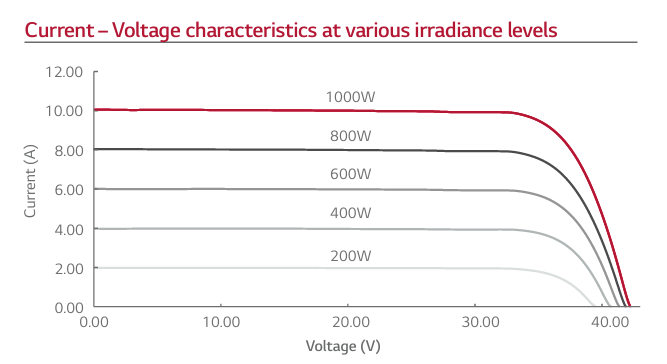

## Cell Conversion
This is for the whole panel. We want to calculate for each individual cell. Current stays constant, but different voltages, resistances and diode ideality. Voltages and ideality can be solved by dividing by number of cells, but resistances need to be found to fit the curve. 60 cells, therefore resulting curves should be voltages of /60 (40/60 = 2/3 = 0.67).

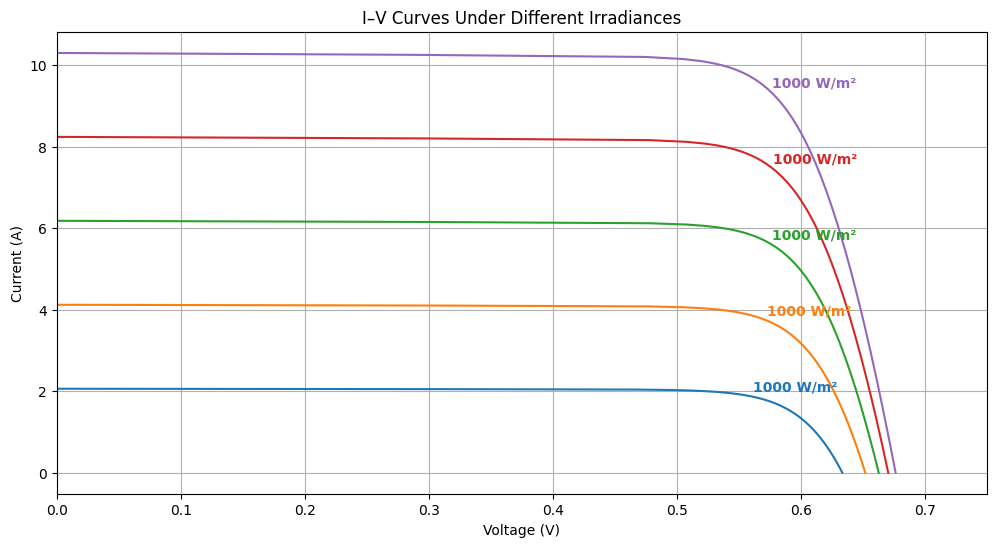

In [6]:
from scipy.optimize import least_squares

def cell_params(V, I, a, iph, isat, rs, rsh, specs):
    points = [(V/specs['N_s'], I) for (V, I) in zip(V,I)]
    a = a / specs['N_s']
    def residuals(x):
        Rs, Rsh = x
        res = []
        for V, I in points:
            I_calc = iph - isat*(np.exp(np.clip((V + I*Rs)/(a), -50, 50)) - 1) - (V + I*Rs)/Rsh
            res.append(I_calc - I)
        return res
    x0 = [rs/specs['N_s'], rsh/specs['N_s']]
    sol = least_squares(residuals, x0, bounds=([0.001, 1],[75, 1e6]),)
    rs, rsh = sol.x
    return a, iph, isat, rs, rsh

plt.figure(figsize=(12, 6))

#adjust parameters for single cell then return 
for i, curve in enumerate(curves):
    V, I = curve
    a, iph, isat, rs, rsh = param_list[i]
    a, iph, isat, rs, rsh = cell_params(V, I, a, iph, isat, rs, rsh, specs)

    #regenerate curves
    V, I = get_curve(a, iph, isat, rs, rsh, specs)

    line = plt.plot(V, I)
    plt.text(V[-20], I[-20] + 0.15, f"{irr} W/m²", color=line[0].get_color(), fontweight='bold')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I–V Curves Under Different Irradiances")
plt.xlim(0, 0.75)
plt.grid(True)




## Cell ANN
Uses the refactored_single_cell.py file to generate a class wide neural network based on data in the training data folder. This contains a series of temperatures and irradiances, and their equivalent 5 parameter model. Cell class also allows setting of temperature/shade to recalculate later. Should match the above graph but faster

Loading existing dataset...


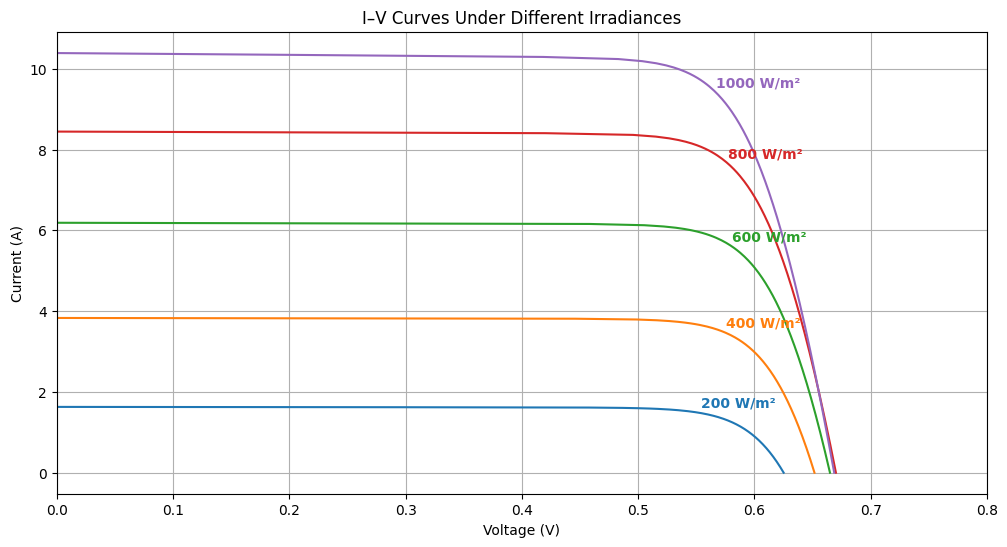

In [7]:
#redo the above single cell calculations with the cell class - uses ANN
plt.figure(figsize=(12, 6))

for i in range(5):
    irr = (i+1)*200

    #generate cells and calc curve
    temp_cell = Cell(irr, 25, "LG_Electronics_Inc__LG330N1T_V5", specs)
    a, iph, isat, rs, rsh = temp_cell.get_params()

    #regenerate curvesPrism_Solar_Technologies_Bi48_267BSTC_pv
    V, I = get_curve(a, iph, isat, rs, rsh, specs)

    line = plt.plot(V, I)
    plt.text(V[-20], I[-20] + 0.15, f"{irr} W/m²", color=line[0].get_color(), fontweight='bold')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I–V Curves Under Different Irradiances")
plt.xlim(0, 0.8)
plt.grid(True)


## Whole Module 
Iterate over a series of voltages for the whole panel, solve the residuals for each voltage, and use to calculate voltage power curve. This can be compared against the paper graphs. Testing with a 60 cell module though instead of 48.

Running Test 1: Unshaded (STC)
Running Test 2: One Substring Shaded
Running Test 3: Two Substrings Lightly Shaded
Running Test 4: Two Substrings Heavily shaded
Running Test 5: Three Substrings Gradient Shade
Running Test 6: Single Cell Heavy Shade
Running Test 7: Uniform Low Irradiance
Running Test 8: One Cell Shaded Per Substring
Comparison Complete


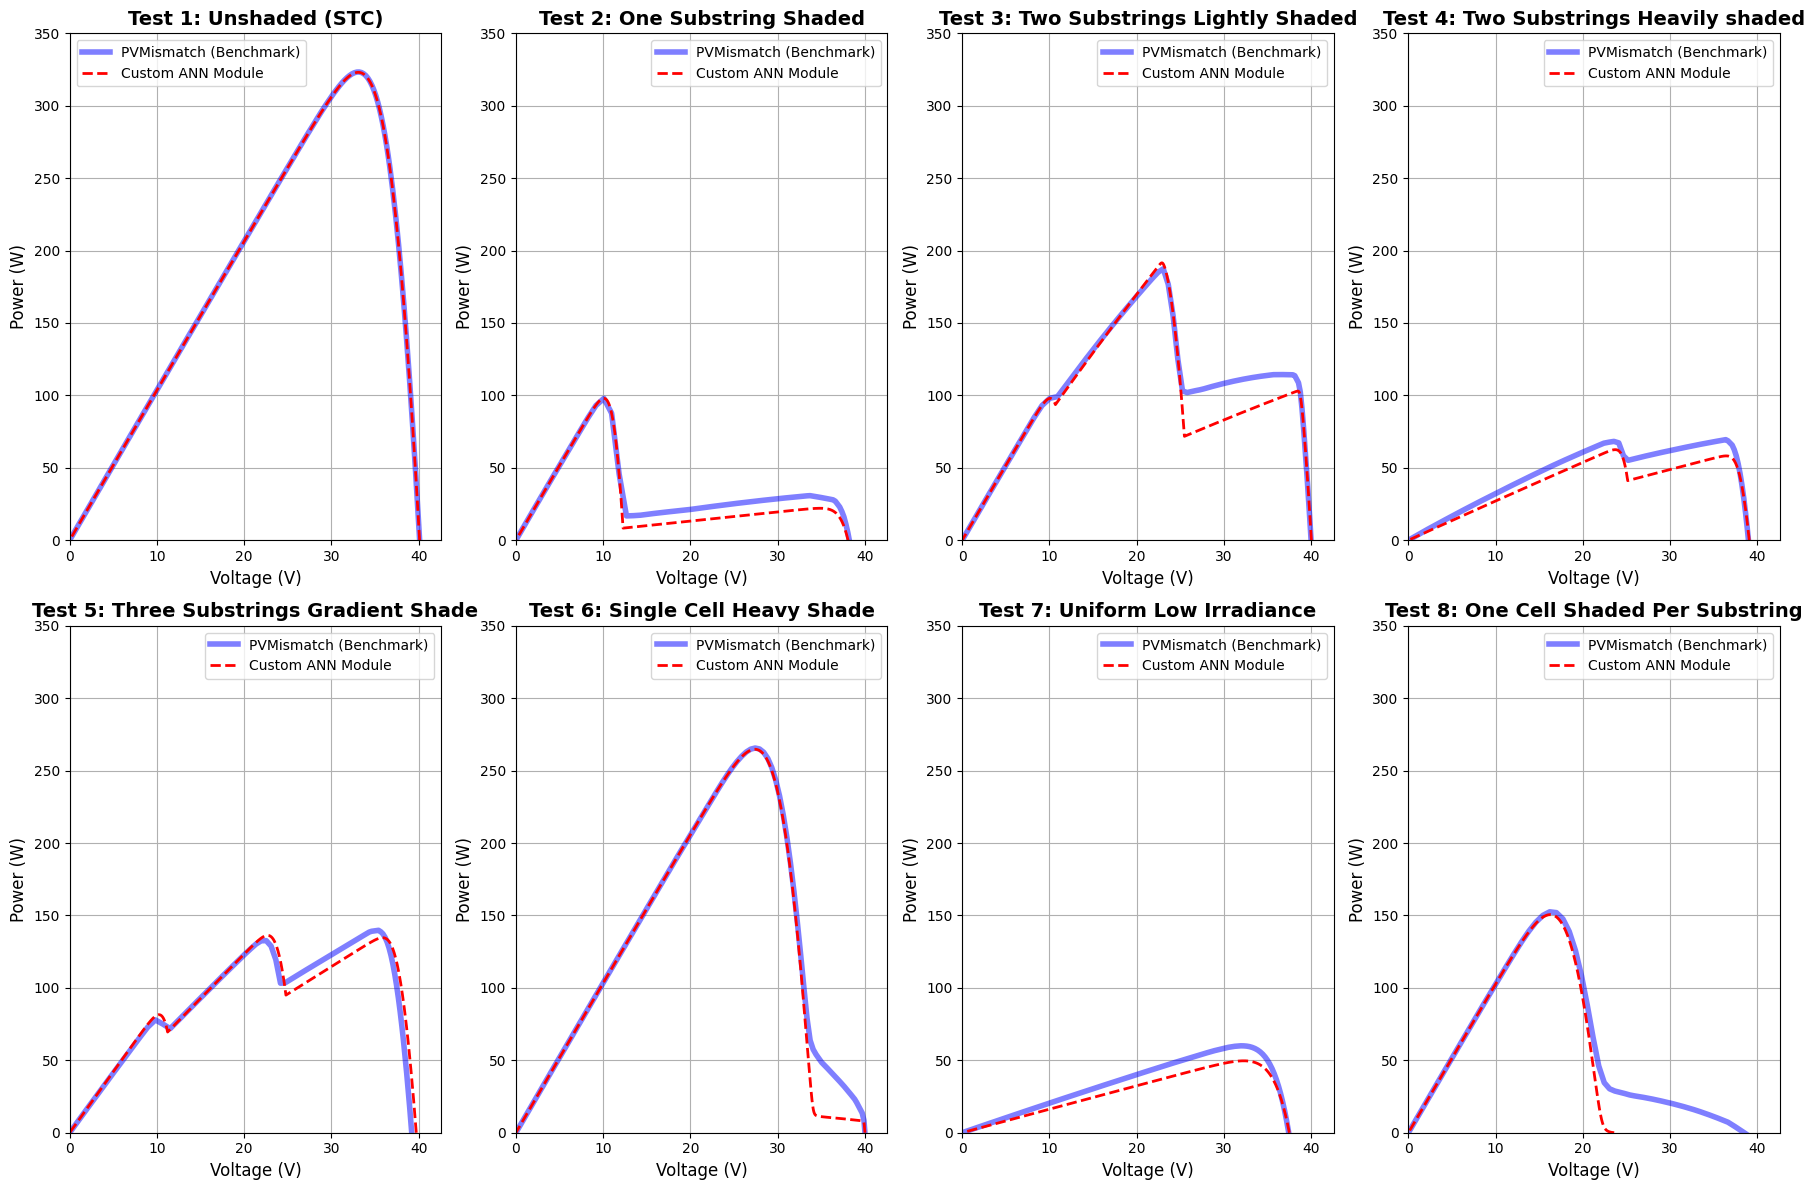

In [ ]:
from pvmismatch import pvsystem
from pvmismatch.pvmismatch_lib import pvmodule, pvstring, pvcell
from pvmismatch.pvmismatch_lib.pvconstants import PVconstants
import matplotlib.pyplot as plt
import numpy as np

#generating our module
module = refactored_whole_module.Module("LG_Electronics_Inc__LG330N1T_V5", specs)
module.d = 3

custom_const = PVconstants()
a, iph, isat, rs, rsh = module.cell_list[0].get_params()
T = 298.15 
Vt_standard = (custom_const.k * T) / custom_const.q
n_ideal = a / Vt_standard
custom_const.k = custom_const.k * n_ideal

lg_cells = [
    pvcell.PVcell(Rs=rs, Rsh=rsh, Isat1_T0=isat, Isat2_T0=0, Isc0_T0=iph, pvconst=custom_const, alpha_Isc=specs['I_sc']) 
    for _ in range(60)
]

custom_layout = pvmodule.standard_cellpos_pat(nrows=20, ncols_per_substr=[1, 1, 1])
panel_60 = pvmodule.PVmodule(cell_pos=custom_layout, pvcells=lg_cells)
panel_string = pvstring.PVstring(numberMods=1, pvmods=[panel_60])
pvmm_sys = pvsystem.PVsystem(numberStrs=1, pvstrs=[panel_string])

#3 test cases
#case 1 unshaded
irr_case_1 = [1000.0] * 60

#case 2 1 substring shaded in substring 1
irr_case_2 = [1000.0] * 60
irr_case_2[0:29] = [100.0] * 29

#case 3 heavy shade in substring 1 and moderate in substring 2
irr_case_3 = [1000.0] * 60
irr_case_3[0:3] = [300.0] * 3
irr_case_3[31:34] = [800.0] * 3

irr_case_4 = [1000.0] * 60
irr_case_4[0:15] = [200.0] * 15
irr_case_4[31:45] = [300.0] * 14

#case 5
irr_case_5 = [1000.0] * 60
irr_case_5[0:20] = [400.0] * 20
irr_case_5[20:40] = [600.0] * 20
irr_case_5[40:60] = [800.0] * 20

#case 6
irr_case_6 = [1000.0] * 60
irr_case_6[10:11] = [50.0] * 1

#case 7
irr_case_7 = [200.0] * 60

#case 8
irr_case_8 = [1000.0] * 60
irr_case_8[0:1] = [10.0] * 1
irr_case_8[20:21] = [10.0] * 1
irr_case_8[40:41] = [10.0] * 1

test_cases = [irr_case_1, irr_case_2, irr_case_3, irr_case_4, irr_case_5, irr_case_6, irr_case_7, irr_case_8]
titles = [
    "Test 1: Unshaded (STC)", 
    "Test 2: One Substring Shaded", 
    "Test 3: Two Substrings Lightly Shaded", 
    "Test 4: Two Substrings Heavily shaded",
    "Test 5: Three Substrings Gradient Shade",
    "Test 6: Single Cell Heavy Shade",
    "Test 7: Uniform Low Irradiance",
    "Test 8: One Cell Shaded Per Substring"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 12))

for i, ax in enumerate(axes.flatten()):
    print(f'Running {titles[i]}')
    current_irr = test_cases[i]

    suns_array = np.array(current_irr) / 1000.0
    pvmm_sys.setSuns({0: {0: suns_array}})
    V_pvmm = pvmm_sys.Vsys.flatten()
    P_pvmm = pvmm_sys.Psys.flatten()

    #custom solver
    module.set_cell_conditions(irr_array=current_irr)
    V_cust, P_cust = module.refactored_iv()

    ax.plot(V_pvmm, P_pvmm, label='PVMismatch (Benchmark)', color='blue', linewidth=4, alpha=0.5)
    ax.plot(V_cust, P_cust, label='Explicit Module Solver', color='red', linestyle='--', linewidth=2)
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel("Voltage (V)", fontsize=12)
    ax.set_ylabel("Power (W)", fontsize=12)
    ax.set_xlim(0, module.voc + 2)
    ax.set_ylim(0, 350)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
print("Comparison Complete")

# Maximum Power Point Tracking
This tends to be slow - so use a max power point tracking method (DPSO) to find the best power. Switches between local and global - global still slowish but local fast. Due to bypass diode should be minimal change between first and second. 3rd shades the last substring - should see a change.

Starting tracker
Converged on power after 8 iterations.
Starting curve
Tracker pmp is 95.61110090898778 and actual is 96.0804733155684
Difference between tracker and actual is 0.46937240658061796
Starting tracker
Converged on power after 14 iterations.
Starting curve
Tracker pmp is 96.10783002448918 and actual is 96.02460592903199
Difference between tracker and actual is 0.08322409545718301
Starting tracker
Converged on power after 12 iterations.
Starting curve
Tracker pmp is 50.409839475148445 and actual is 50.21550598755801
Difference between tracker and actual is 0.19433348759043412


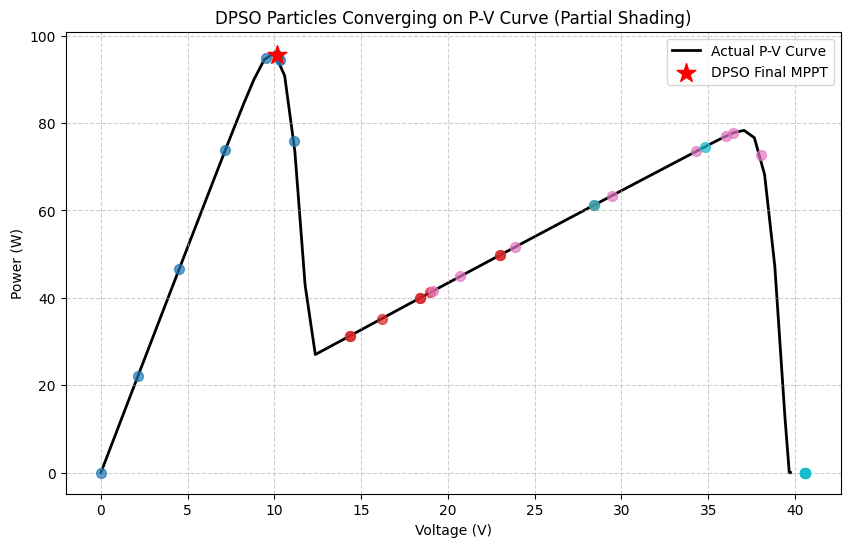

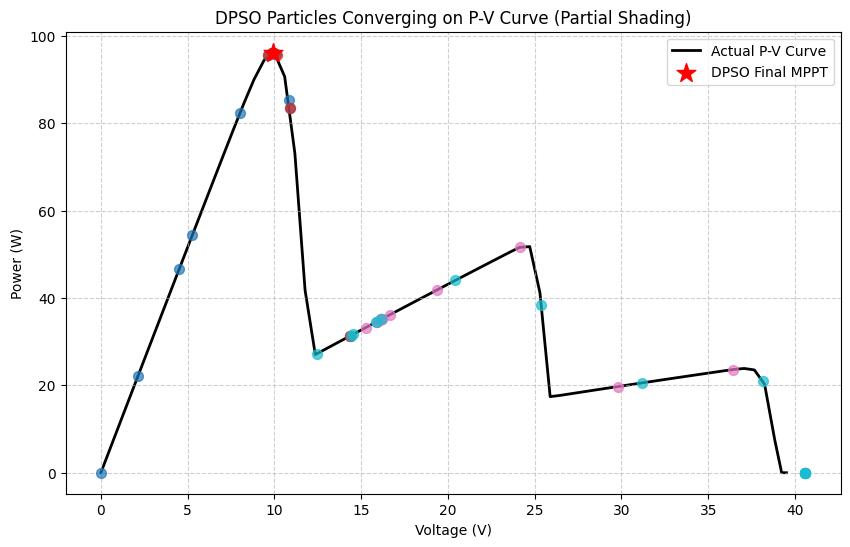

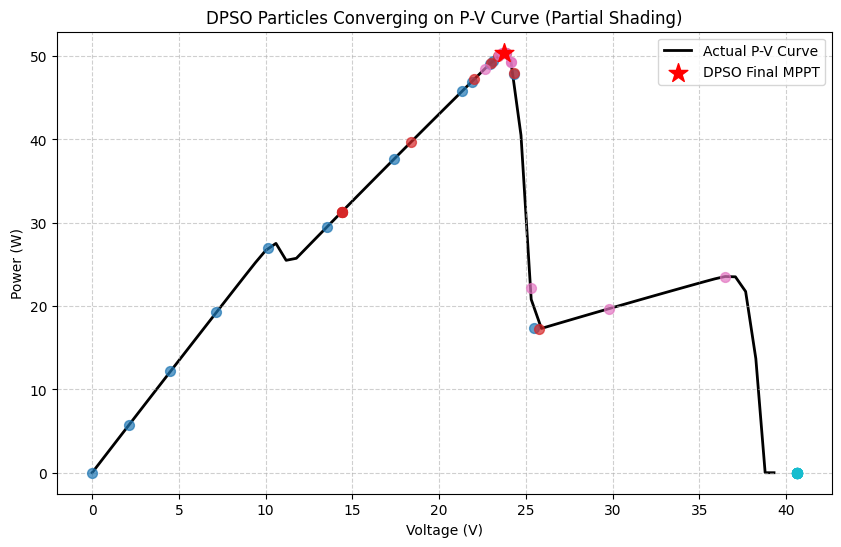

In [9]:
import matplotlib.cm as cm
module.d = 3
#the dpso takes in a min/max load, the module and the number of particles used to track
tracker = DPSO_MPPT.DPSO_MPPT(num_particles=4, module=module, RL_min=0, RL_max=module.voc)

#irr array - want to show 2 peaks
irr_array = [1000.0] * 60
irr_array[6:14] = [250] * 8
irr_array[43:50] = [250] * 7

#calculate using the tracker & the full graph
print("Starting tracker")
tracker.set_module_conditions(irr_array=irr_array)
tracker_vmp, tracker_pmp, history = tracker.track_mpp()
print("Starting curve")
V, P = module.calculate_iv()
module_pmp = P[np.argmax(P)]

print(f'Tracker pmp is {tracker_pmp} and actual is {module_pmp}')
print(f'Difference between tracker and actual is {np.abs(tracker_pmp - module_pmp)}')

plt.figure(figsize=(10, 6))
plt.plot(V, P, label='Actual P-V Curve', color='black', linewidth=2, zorder=1)
g_num_particles = len(history[0]['voltages'])
colors = cm.tab10(np.linspace(0, 1, g_num_particles))
for p_idx in range(g_num_particles):
    p_voltages = [step['voltages'][p_idx] for step in history]
    p_powers = [step['powers'][p_idx] for step in history]
    plt.scatter(p_voltages, p_powers, color=colors[p_idx], s=50, alpha=0.7, zorder=2)

plt.scatter(tracker_vmp, tracker_pmp, color='red', marker='*', s=200, label='DPSO Final MPPT', zorder=3)

plt.title('DPSO Particles Converging on P-V Curve (Partial Shading)')
plt.xlabel('Voltage (V)')
plt.ylabel('Power (W)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#update slightly in local mode
irr_array[6:18] = [100] * 12
print("Starting tracker")
tracker.set_module_conditions(irr_array=irr_array)
tracker_vmp, tracker_pmp, history = tracker.track_mpp()
print("Starting curve")
V, P = module.calculate_iv()
module_pmp = P[np.argmax(P)]

print(f'Tracker pmp is {tracker_pmp} and actual is {module_pmp}')
print(f'Difference between tracker and actual is {np.abs(tracker_pmp - module_pmp)}')

plt.figure(figsize=(10, 6))
plt.plot(V, P, label='Actual P-V Curve', color='black', linewidth=2, zorder=1)
g_num_particles = len(history[0]['voltages'])
colors = cm.tab10(np.linspace(0, 1, g_num_particles))
for p_idx in range(g_num_particles):
    p_voltages = [step['voltages'][p_idx] for step in history]
    p_powers = [step['powers'][p_idx] for step in history]
    plt.scatter(p_voltages, p_powers, color=colors[p_idx], s=50, alpha=0.7, zorder=2)

plt.scatter(tracker_vmp, tracker_pmp, color='red', marker='*', s=200, label='DPSO Final MPPT', zorder=3)

plt.title('DPSO Particles Converging on P-V Curve (Partial Shading)')
plt.xlabel('Voltage (V)')
plt.ylabel('Power (W)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#update - should change to global mode
irr_array[22:34] = [300] * 12
print("Starting tracker")
tracker.set_module_conditions(irr_array=irr_array)
tracker_vmp, tracker_pmp, history = tracker.track_mpp()
print("Starting curve")
V, P = module.calculate_iv()
module_pmp = P[np.argmax(P)]

print(f'Tracker pmp is {tracker_pmp} and actual is {module_pmp}')
print(f'Difference between tracker and actual is {np.abs(tracker_pmp - module_pmp)}')

plt.figure(figsize=(10, 6))
plt.plot(V, P, label='Actual P-V Curve', color='black', linewidth=2, zorder=1)
g_num_particles = len(history[0]['voltages'])
colors = cm.tab10(np.linspace(0, 1, g_num_particles))
for p_idx in range(g_num_particles):
    p_voltages = [step['voltages'][p_idx] for step in history]
    p_powers = [step['powers'][p_idx] for step in history]
    plt.scatter(p_voltages, p_powers, color=colors[p_idx], s=50, alpha=0.7, zorder=2)

plt.scatter(tracker_vmp, tracker_pmp, color='red', marker='*', s=200, label='DPSO Final MPPT', zorder=3)

plt.title('DPSO Particles Converging on P-V Curve (Partial Shading)')
plt.xlabel('Voltage (V)')
plt.ylabel('Power (W)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


# Power Over Time Calculation 
This uses the day data extracted into the simulation data folder to generate the power over time curve. Uses the explicit solar model. Runs in ~5 minutes.
![Solar GIF](results/shading_data/shadinganimation.gif)


step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
step 19
step 20
step 21
step 22
step 23
step 24
step 25
step 26
step 27
step 28
step 29
step 30
step 31
step 32
step 33
step 34
step 35
step 36
step 37
step 38
step 39
step 40
step 41
step 42
step 43
step 44
step 45
step 46
step 47
step 48
step 49
step 50
step 51
step 52
step 53
step 54
step 55
step 56
step 57
step 58
step 59
step 60
step 61
step 62
step 63
step 64
step 65
step 66
step 67
step 68
step 69
step 70
step 71
step 72
step 73
step 74
step 75
step 76
step 77
step 78
step 79
step 80
step 81
step 82
step 83
step 84
step 85
step 86
step 87
step 88
step 89
step 90
step 91
step 92
step 93
step 94
step 95
step 96
step 97
step 98
step 99
step 100
step 101
step 102
step 103
step 104
step 105
step 106
step 107
step 108
step 109
step 110
step 111
step 112
step 113
step 114
step 115
step 116
step 117
step 118
step 119
step 120
step 121
step 122
ste

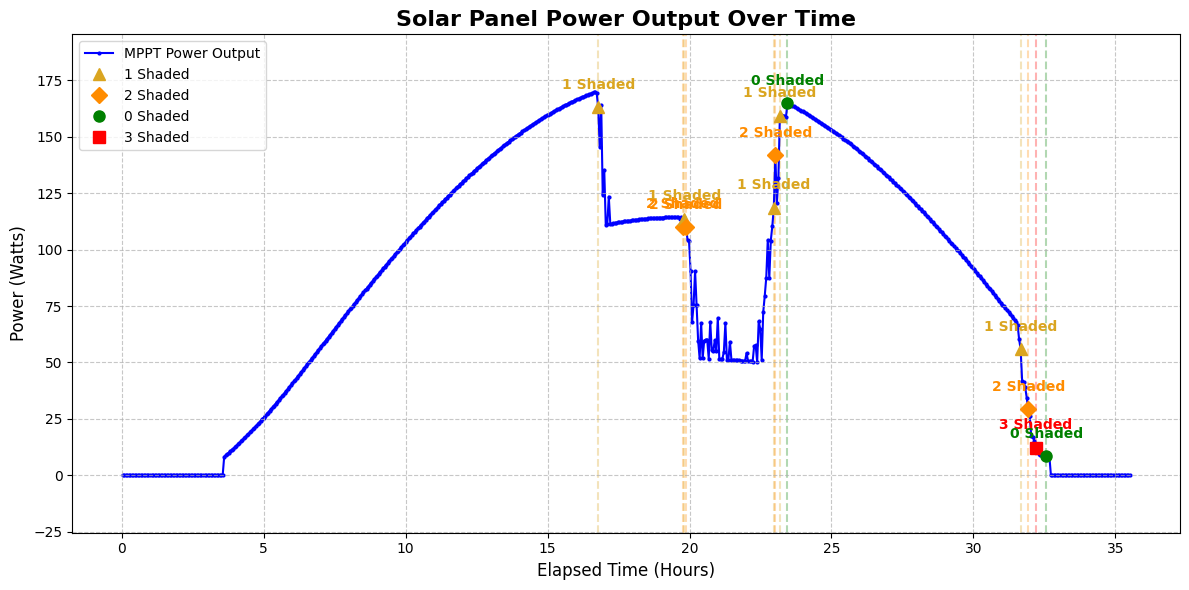

In [5]:
from frontend_reqs.data_to_pmp import run_shade_to_pmp_new
from frontend_reqs.graphing import plot_power_data
import pvlib
import os

#create the 48 cell module
cec_modules = pvlib.pvsystem.retrieve_sam('CECmod')
module = cec_modules['Prism_Solar_Technologies_Bi48_267BSTC']
module_name = 'Prism_Solar_Technologies_Bi48_267BSTC'
specs = {
    'tech': module['Technology'],
    'N_s': module['N_s'],
    'I_sc': module['I_sc_ref'],
    'V_oc': module['V_oc_ref'],
    'I_mp': module['I_mp_ref'],
    'V_mp': module['V_mp_ref'],
    'alpha_sc': module['alpha_sc'],
    'beta_oc': module['beta_oc'],
    'gamma': module['gamma_r']/100
}

module = refactored_whole_module.Module('Prism_Solar_Technologies_Bi48_267BSTC', specs)

#hold data in a folder
target_dir = os.path.join("frontend_reqs", "simulation_data")

#ensure folder exists
os.makedirs(target_dir, exist_ok=True)

#finds input and output file
input_csv = os.path.join(target_dir, "Saved_Irradiance_Data.csv")
output_csv = os.path.join(target_dir, "Saved_Power_Time_Data.csv")

#run data then graphing with the data
run_shade_to_pmp_new(module, input_csv, output_csv)
plot_power_data(output_csv)

